## 1. Imports e carregamento

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# 1. Carregar o CSV de resultados
df = pd.read_csv("./data/dados__resultados_teste_classificacao.csv", sep=",", encoding="utf-8")

# Remover linhas de metadados (a segunda linha do CSV tem tipos de colunas)
df = df[pd.to_numeric(df["gb sk (II)"], errors="coerce").notna()].copy()

print(f"Shape: {df.shape}")
df.head()

Shape: (2637, 232)


,ROTULO_IDEB,CO_ENTIDADE,gb sk,gb sk (II),gb sk (MI),gb sk (MM),gb sk (MS),gb sk (error),SG_UF,TP_DEPENDENCIA,...,IN_ESP_EXCLUSIVA_PRE,IN_ESP_EXCLUSIVA_FUND_AI,IN_ESP_EXCLUSIVA_FUND_AF,IN_ESP_EXCLUSIVA_MEDIO_MEDIO,IN_ESP_EXCLUSIVA_MEDIO_INTEGR,IN_COMUM_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_ESP_EXCLUSIVA_PROF
2,MI,35918787,MM,0.00023423,0.278291,0.721475,5.17302e-08,0.721709,SP,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MI,52103064,MI,0.00029455,0.71666,0.283045,1.11525e-07,0.28334,GO,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MI,33053391,MI,0.000666293,0.971853,0.027481,4.16352e-08,0.0281473,RJ,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,MI,29070350,MI,0.00778334,0.979204,0.013013,1.89712e-08,0.0207964,BA,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,MI,15170438,MI,0.00125557,0.991526,0.00721878,2.58049e-08,0.00847438,PA,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Definir colunas e preparar dados
## Rótulos IDEB 2025

| Sigla | Significado      | Faixa                  |
|-------|------------------|------------------------|
| SS    | Superior         | 9,0 a 10               |
| MS    | Médio Superior   | 7,0 a 8,9              |
| MM    | Médio            | 5,0 a 6,9              |
| MI    | Médio Inferior   | 3,0 a 4,9              |
| II    | Inferior         | 0,0 a 2,9              |
| SR    | Sem Rendimento   | Zero (ou ausente/nulo) |

In [5]:
# Colunas de probabilidade do modelo
PROB_COLS = [
    "gb sk (II)",
    "gb sk (MI)",
    "gb sk (MM)",
    "gb sk (MS)"
]
CLASSES = ["II", "MI", "MM", "MS"]

# Converter para numérico
for col in PROB_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Classe prevista = argmax das probabilidades
df["PREDITO"] = df[PROB_COLS].idxmax(axis=1).str.extract(r"\((\w+)\)")[0]

# Classe real
df["REAL"] = df["ROTULO_IDEB"].astype(str).str.strip()

# Confiança da previsão
df["CONFIANCA"] = df[PROB_COLS].max(axis=1)

# Remover classes não usadas no treino (SS e SR não aparecem nas probs)
df = df[df["REAL"].isin(CLASSES)].copy()

print(f"Registros válidos: {len(df)}")
print("\nDistribuição real:")
print(df["REAL"].value_counts().reindex(CLASSES))
print("\nDistribuição prevista:")
print(df["PREDITO"].value_counts().reindex(CLASSES))

Registros válidos: 2637

Distribuição real:
REAL
II      40
MI    2027
MM     564
MS       6
Name: count, dtype: int64

Distribuição prevista:
PREDITO
II      27
MI    2265
MM     339
MS       6
Name: count, dtype: int64


## Métricas gerais

In [6]:
# Métricas globais
acc = accuracy_score(df["REAL"], df["PREDITO"])
f1_macro = f1_score(df["REAL"], df["PREDITO"], average="macro")
f1_weighted = f1_score(df["REAL"], df["PREDITO"], average="weighted")
prec = precision_score(df["REAL"], df["PREDITO"], average="macro", zero_division=0)
rec = recall_score(df["REAL"], df["PREDITO"], average="macro", zero_division=0)

print("=" * 50)
print("MÉTRICAS GERAIS")
print("=" * 50)
print(f"Acurácia........: {acc:.4f}")
print(f"F1 macro........: {f1_macro:.4f}")
print(f"F1 weighted.....: {f1_weighted:.4f}")
print(f"Precisão macro..: {prec:.4f}")
print(f"Recall macro....: {rec:.4f}")
print("=" * 50)

print("\nRelatório completo por classe:")
print(classification_report(df["REAL"], df["PREDITO"], labels=CLASSES, zero_division=0))

MÉTRICAS GERAIS
Acurácia........: 0.8024
F1 macro........: 0.4015
F1 weighted.....: 0.7841
Precisão macro..: 0.4447
Recall macro....: 0.3804

Relatório completo por classe:
              precision    recall  f1-score   support

          II       0.30      0.20      0.24        40
          MI       0.83      0.93      0.88      2027
          MM       0.65      0.39      0.49       564
          MS       0.00      0.00      0.00         6

    accuracy                           0.80      2637
   macro avg       0.44      0.38      0.40      2637
weighted avg       0.78      0.80      0.78      2637



## Matriz de confusão

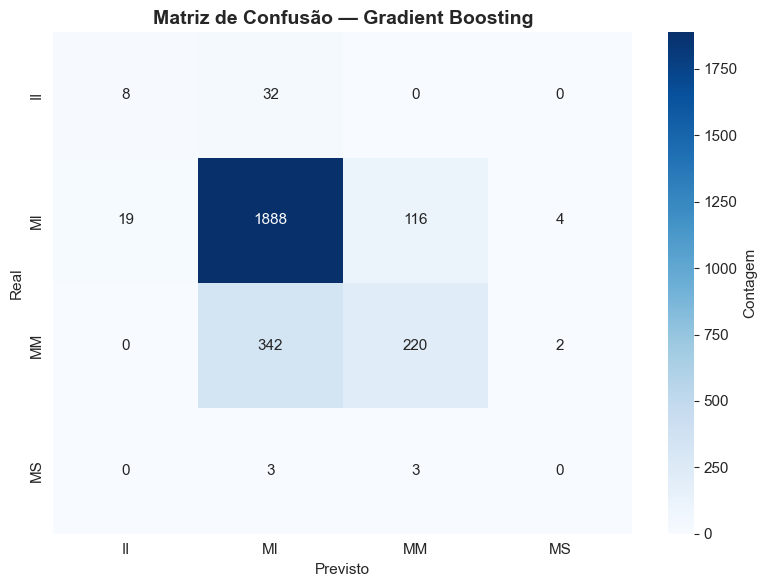

In [7]:
# Matriz de confusão
cm = confusion_matrix(df["REAL"], df["PREDITO"], labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    cbar_kws={"label": "Contagem"}, ax=ax
)
ax.set_title("Matriz de Confusão — Gradient Boosting",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Matriz de confusão normalizada (%)

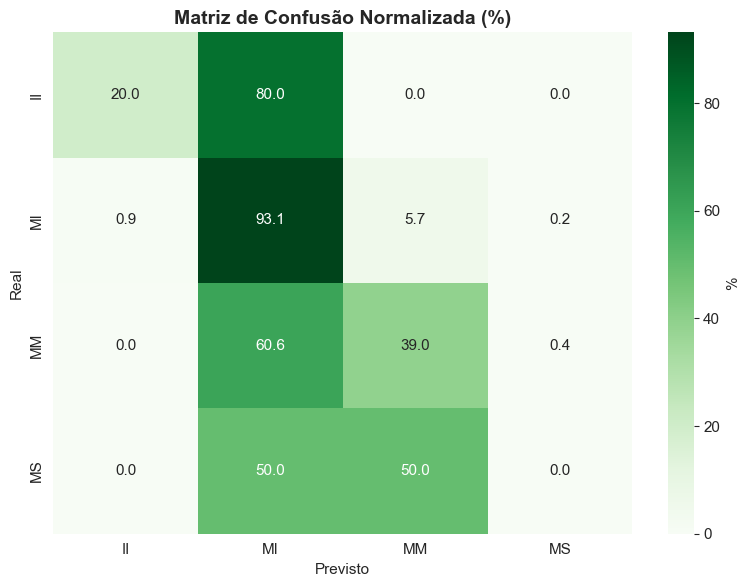

In [8]:
# Normalizada por linha (recall visual)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".1f", cmap="Greens",
    xticklabels=CLASSES, yticklabels=CLASSES,
    cbar_kws={"label": "%"}, ax=ax
)
ax.set_title("Matriz de Confusão Normalizada (%)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Distribuição real vs prevista

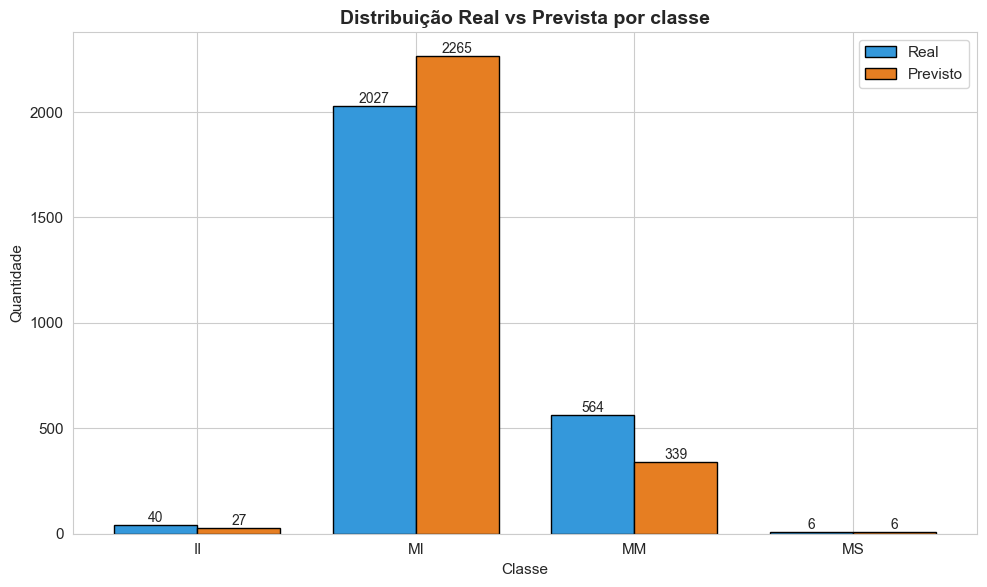

In [9]:
real_counts = df["REAL"].value_counts().reindex(CLASSES, fill_value=0)
pred_counts = df["PREDITO"].value_counts().reindex(CLASSES, fill_value=0)

x = np.arange(len(CLASSES))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, real_counts.values, width, label="Real",
               color="#3498db", edgecolor="black")
bars2 = ax.bar(x + width/2, pred_counts.values, width, label="Previsto",
               color="#e67e22", edgecolor="black")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{int(h)}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_title("Distribuição Real vs Prevista por classe",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
ax.legend()
plt.tight_layout()
plt.show()

## Distribuição da confiança do modelo

C:\Users\clara\AppData\Local\Temp\ipykernel_13144\451922002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


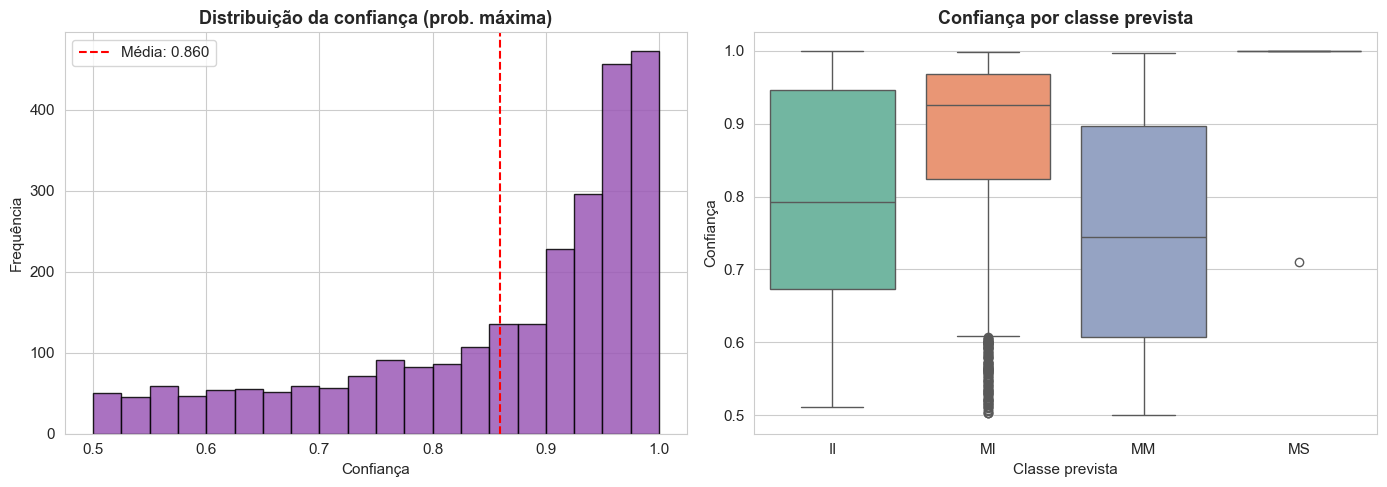

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma geral
axes[0].hist(df["CONFIANCA"], bins=20, color="#9b59b6",
             edgecolor="black", alpha=0.85)
axes[0].axvline(df["CONFIANCA"].mean(), color="red", linestyle="--",
                label=f"Média: {df['CONFIANCA'].mean():.3f}")
axes[0].set_title("Distribuição da confiança (prob. máxima)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Confiança")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Boxplot por classe prevista
sns.boxplot(
    data=df, x="PREDITO", y="CONFIANCA",
    order=CLASSES, palette="Set2", ax=axes[1]
)
axes[1].set_title("Confiança por classe prevista",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Classe prevista")
axes[1].set_ylabel("Confiança")

plt.tight_layout()
plt.show()

## Erros do modelo (casos mal classificados)

In [11]:
erros = df[df["REAL"] != df["PREDITO"]].copy()

print(f"Total de erros: {len(erros)} de {len(df)} ({len(erros)/len(df)*100:.2f}%)")
print("\nPrincipais confusões (Real → Previsto):")
if len(erros) > 0:
    confusoes = erros.groupby(["REAL", "PREDITO"]).size().sort_values(ascending=False)
    print(confusoes)
else:
    print("Nenhum erro! Para o conjunto de teste, o modelo acertou todas as previsões.")

Total de erros: 521 de 2637 (19.76%)

Principais confusões (Real → Previsto):
REAL  PREDITO
MM    MI         342
MI    MM         116
II    MI          32
MI    II          19
      MS           4
MS    MI           3
      MM           3
MM    MS           2
dtype: int64


## Top-N erros com maior confiança

In [12]:
if len(erros) > 0:
    top_erros = erros.sort_values("CONFIANCA", ascending=False).head(10)
    cols_show = ["CO_ENTIDADE", "SG_UF", "REAL", "PREDITO", "CONFIANCA"] + PROB_COLS
    cols_show = [c for c in cols_show if c in top_erros.columns]
    display(top_erros[cols_show])
else:
    print("Sem erros para exibir.")

,CO_ENTIDADE,SG_UF,REAL,PREDITO,CONFIANCA,gb sk (II),gb sk (MI),gb sk (MM),gb sk (MS)
510,52056260,GO,MI,MS,1.000000,1.785310e-11,4.490380e-08,6.851740e-09,1.000000e+00
412,31158879,MG,MI,MS,1.000000,1.024270e-10,2.050420e-07,3.233490e-09,1.000000e+00
436,52062546,GO,MM,MS,1.000000,2.009450e-11,8.629660e-09,3.062440e-08,1.000000e+00
1291,32026480,ES,MI,MS,1.000000,6.055810e-13,7.767460e-10,3.602480e-10,1.000000e+00
1934,52086062,GO,MI,MS,1.000000,1.135190e-11,2.964180e-08,5.532900e-10,1.000000e+00
76,21143129,MA,MI,II,0.999992,9.999920e-01,7.951510e-06,1.303500e-07,1.479730e-13
1667,11033819,RO,MI,II,0.999915,9.999150e-01,8.408970e-05,1.095810e-06,1.878010e-12
231,33055610,RJ,MM,MI,0.990717,1.000340e-03,9.907170e-01,8.282730e-03,1.377070e-08
1068,21253676,MA,II,MI,0.989906,3.404500e-03,9.899060e-01,6.689420e-03,2.384080e-08
615,33051070,RJ,II,MI,0.989363,1.620430e-03,9.893630e-01,9.016330e-03,3.344280e-08


## Resumo final (tabela)

In [13]:
resumo = pd.DataFrame({
    "Classe": CLASSES,
    "Suporte (real)": [int((df["REAL"] == c).sum()) for c in CLASSES],
    "Previstos": [int((df["PREDITO"] == c).sum()) for c in CLASSES],
    "Acertos": [int(((df["REAL"] == c) & (df["PREDITO"] == c)).sum()) for c in CLASSES],
})
resumo["Recall (%)"] = (resumo["Acertos"] / resumo["Suporte (real)"] * 100).round(2)
resumo["Confiança média"] = [
    round(df.loc[df["PREDITO"] == c, "CONFIANCA"].mean(), 4) if (df["PREDITO"] == c).any() else 0
    for c in CLASSES
]

print("=" * 70)
print("RESUMO POR CLASSE")
print("=" * 70)
print(resumo.to_string(index=False))
print("=" * 70)

RESUMO POR CLASSE
Classe  Suporte (real)  Previstos  Acertos  Recall (%)  Confiança média
    II              40         27        8       20.00           0.7999
    MI            2027       2265     1888       93.14           0.8768
    MM             564        339      220       39.01           0.7500
    MS               6          6        0        0.00           0.9517
